# $\mathrm{Na}_{\mathrm{V}}1.5$ intracellular-pore shape

This notebook asks whether the four-domain intracellular gate is sampled as a more square or more rectangular opening. The analysis is inspired by structural descriptions of an approximately square open pore and a more anisotropic, rectangular closed pore.

The four vertices are the Cα positions of DI M415, DII A742, DIII I1154, and DIV I1455 in the model numbering. Four perimeter distances describe the outline and two diagonals describe the cross-pore opening. The **mean diagonal** is used as a size proxy, while the **side aspect ratio** separates square-like shapes (near 1) from increasingly rectangular shapes (>1). These are continuous geometric descriptors, not hard state assignments.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd() / "shared").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from shared.plotting import NAV15_PALETTE, apply_kv21_style
from shared.nav15_pore_shape import (
    NAV15_GATE_COLUMNS,
    ensemble_gate_shape,
    experimental_gate_shape,
    plot_shape_landscape,
    plot_shape_distributions,
    plot_representative_shapes,
)

apply_kv21_style()
nav_dir = repo_root / "nav15"
data_dir = nav_dir / "dataDistances"
experimental_dir = nav_dir / "experimental"
writing_figure_dir = repo_root.parent / "vgci_mutants_writing" / "figures" / "nav15"
writing_figure_dir.mkdir(parents=True, exist_ok=True)

## Ensembles and experimental references

WT and QQQ are kept separate because the mutation changes the IFM motif, whereas masked and masked-v2 describe distinct masking profiles. WT masked-v2 noIFM retains evolutionary information for the IFM itself.

The experimental panel includes native/full-length, engineered, and intermediate structures. 8T6L is shown as a toxin-bound comparator, not as a native open-state target.

In [2]:
DATASETS = {
    "WT | vanilla": ("26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["WT_VAN"]),
    "WT | masked v2": ("26-07-27_Nav15_wt_maskedv2_AF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["WT_MASKED_V2"]),
    "WT | masked v2 noIFM": ("26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["WT_MASKED_V2_NOIFM"]),
    "QQQ | vanilla": ("26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["QQQ_VAN"]),
    "QQQ | masked": ("26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["QQQ_MASKED"]),
    "QQQ | masked v2": ("26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_ok_rmsd_3A.csv", NAV15_PALETTE["QQQ_MASKED_V2"]),
}

palette = {label: color for label, (_, color) in DATASETS.items()}
ensemble_parts = []
for label, (filename, _) in DATASETS.items():
    frame = pd.read_csv(data_dir / filename)
    ensemble_parts.append(ensemble_gate_shape(frame, label))
ensemble_shape = pd.concat(ensemble_parts, ignore_index=True)

experimental_shape, experimental_distance_audit = experimental_gate_shape(experimental_dir)
print(f"AF2 models analyzed: {len(ensemble_shape):,}")
display(experimental_shape[["dataset", "state", "mean_diagonal_A", "side_aspect_ratio", "opposite_side_mismatch", "diagonal_mismatch"]].round(3))

AF2 models analyzed: 29,998


,dataset,state,mean_diagonal_A,side_aspect_ratio,opposite_side_mismatch,diagonal_mismatch
0,6UZ3,WT inactivated,15.468,1.121,0.184,0.137
1,7FBS,QQQ engineered open,16.799,1.203,0.143,0.213
2,8T6L,BTX-B-bound comparator,15.508,1.091,0.203,0.096
3,7DTC,E1784K intermediate-inactivated,15.172,1.115,0.251,0.069
4,8VYJ,"full-length open, Model I",16.543,1.100,0.209,0.094
5,8VYK,"full-length expanded open, Model II",17.044,1.137,0.170,0.061


## Size and shape are related, but not interchangeable

The landscape below places pore-opening size on the horizontal axis and rectangular anisotropy on the vertical axis. Each small point is one AF2 model; the larger filled point is that ensemble's median. Experimental structures are outlined symbols. A structure can therefore move toward a larger opening without becoming more square, or become more square without a large change in its mean diagonal.

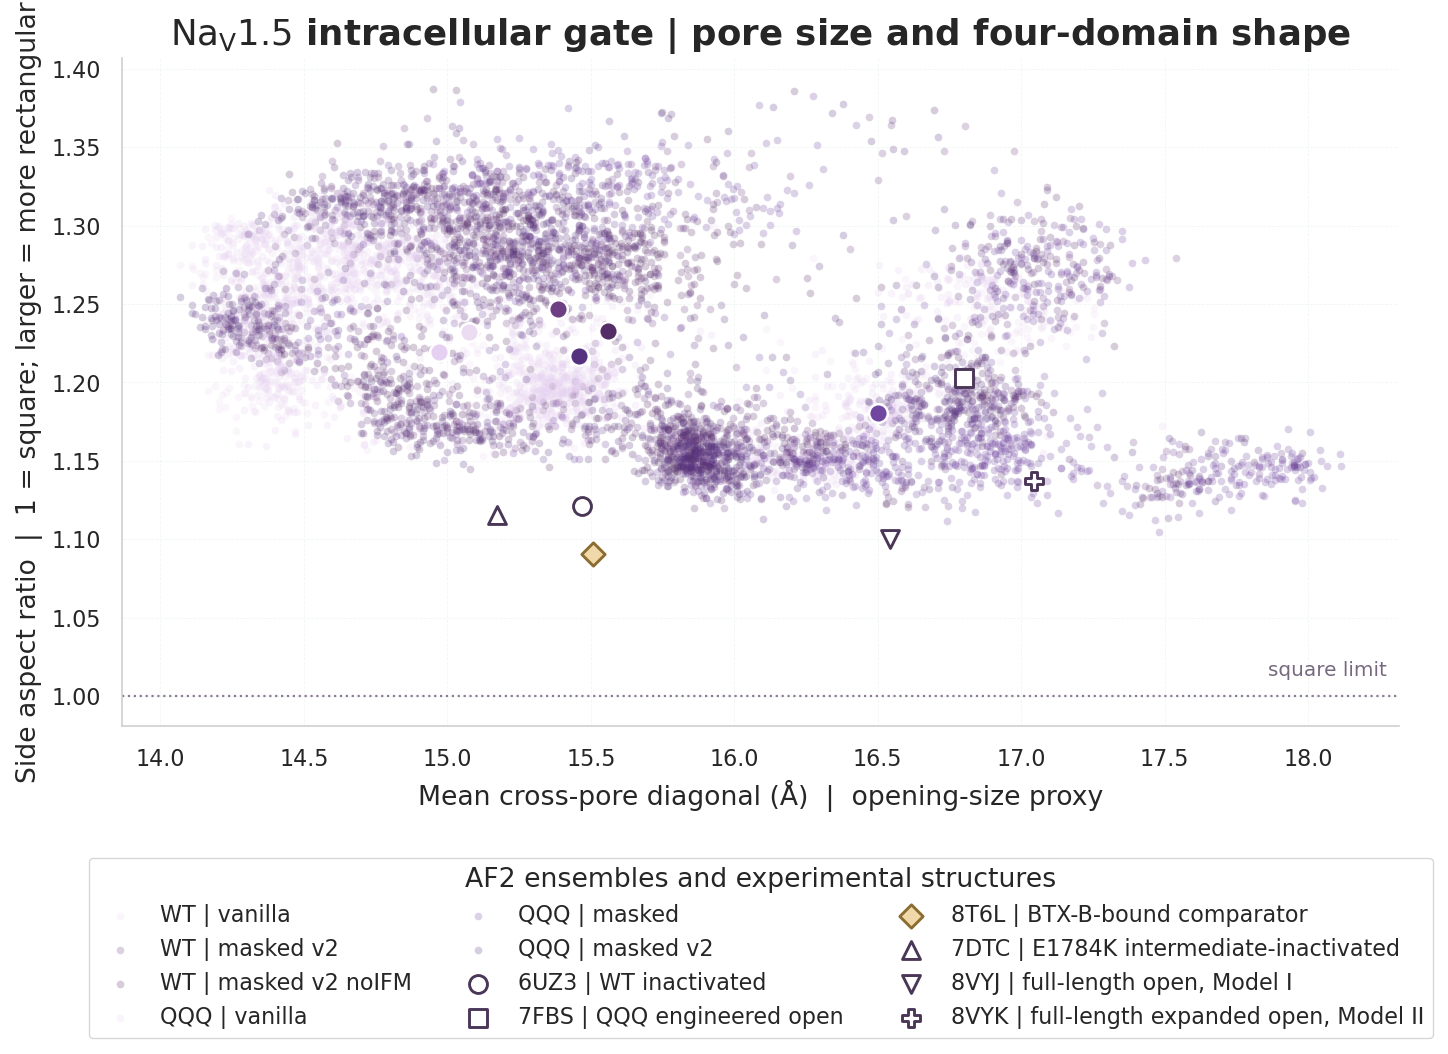

In [3]:
fig, ax = plot_shape_landscape(ensemble_shape, experimental_shape, palette)
fig.savefig(writing_figure_dir / "Nav15_gate_shape_landscape.png", dpi=300, bbox_inches="tight")
fig.savefig(writing_figure_dir / "Nav15_gate_shape_landscape.pdf", bbox_inches="tight")
plt.show()

## Full square-to-rectangle distributions

The violin view makes changes in sampling breadth and multimodality visible. Experimental markers are repeated over each ensemble only as fixed geometric references; they are not ensemble observations. The toxin-bound 8T6L point is visually distinguished in tan.

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/nav15_pore_shape.py:263: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


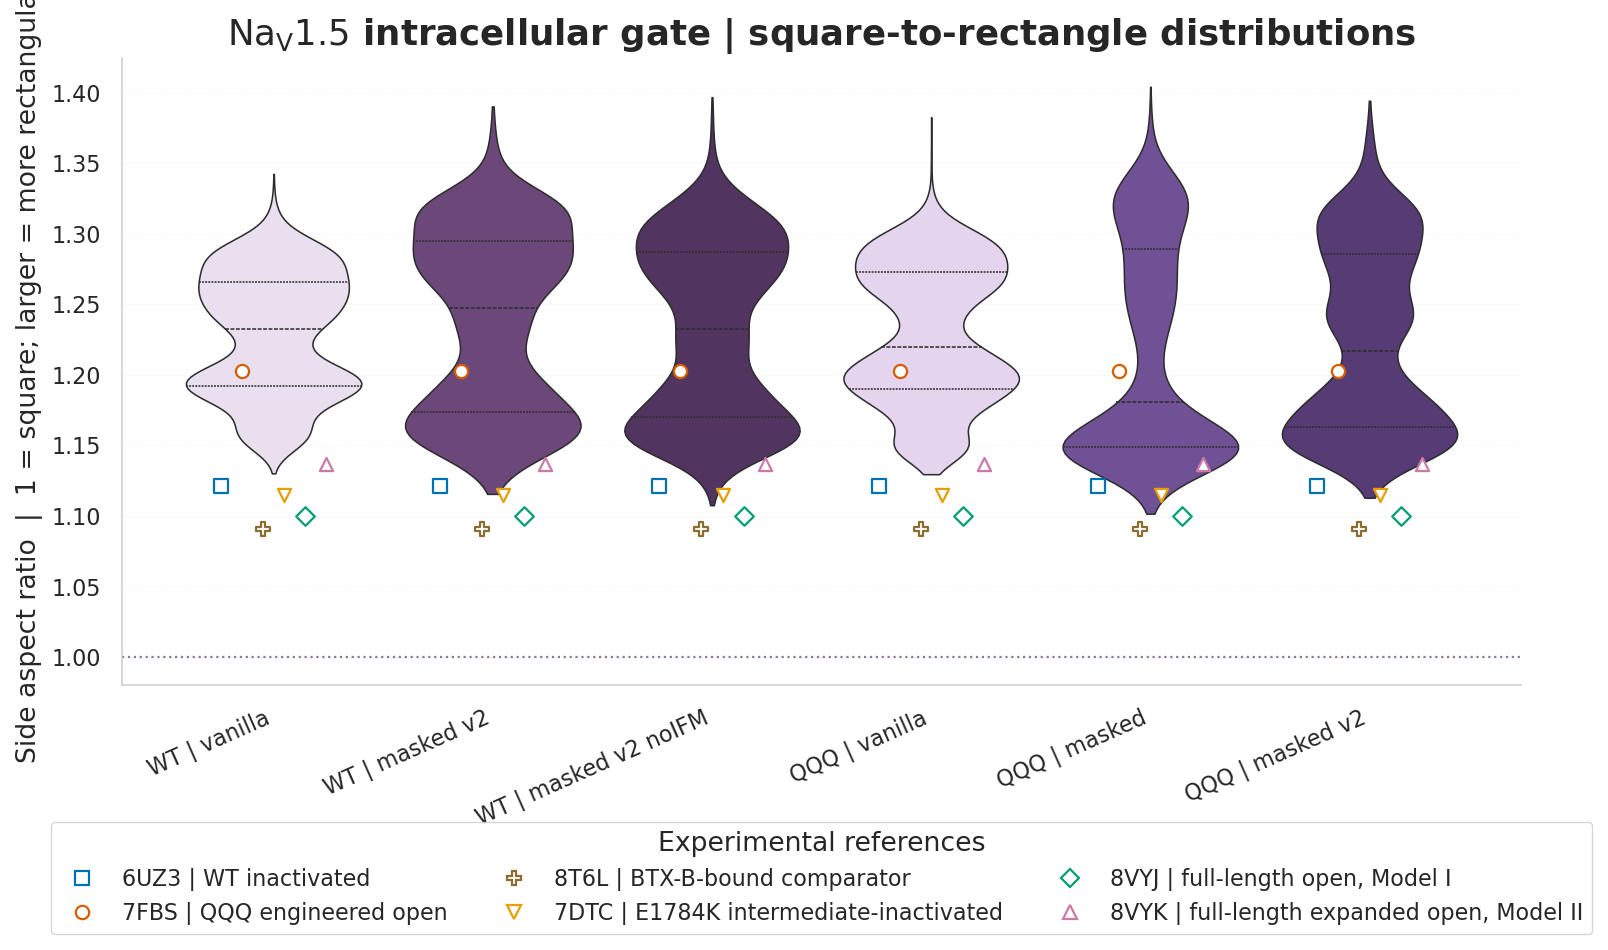

In [4]:
fig, ax = plot_shape_distributions(ensemble_shape, experimental_shape, palette)
fig.savefig(writing_figure_dir / "Nav15_gate_shape_distributions.png", dpi=300, bbox_inches="tight")
fig.savefig(writing_figure_dir / "Nav15_gate_shape_distributions.pdf", bbox_inches="tight")
plt.show()

## Reconstructed pore outlines

For an intuitive top-down view, the six median distances for each ensemble are embedded in their best-fitting two-dimensional plane. These outlines preserve distances and scale in ångströms; they are not structural superpositions. Domain labels fix the vertex correspondence so rotations do not create an apparent state difference.

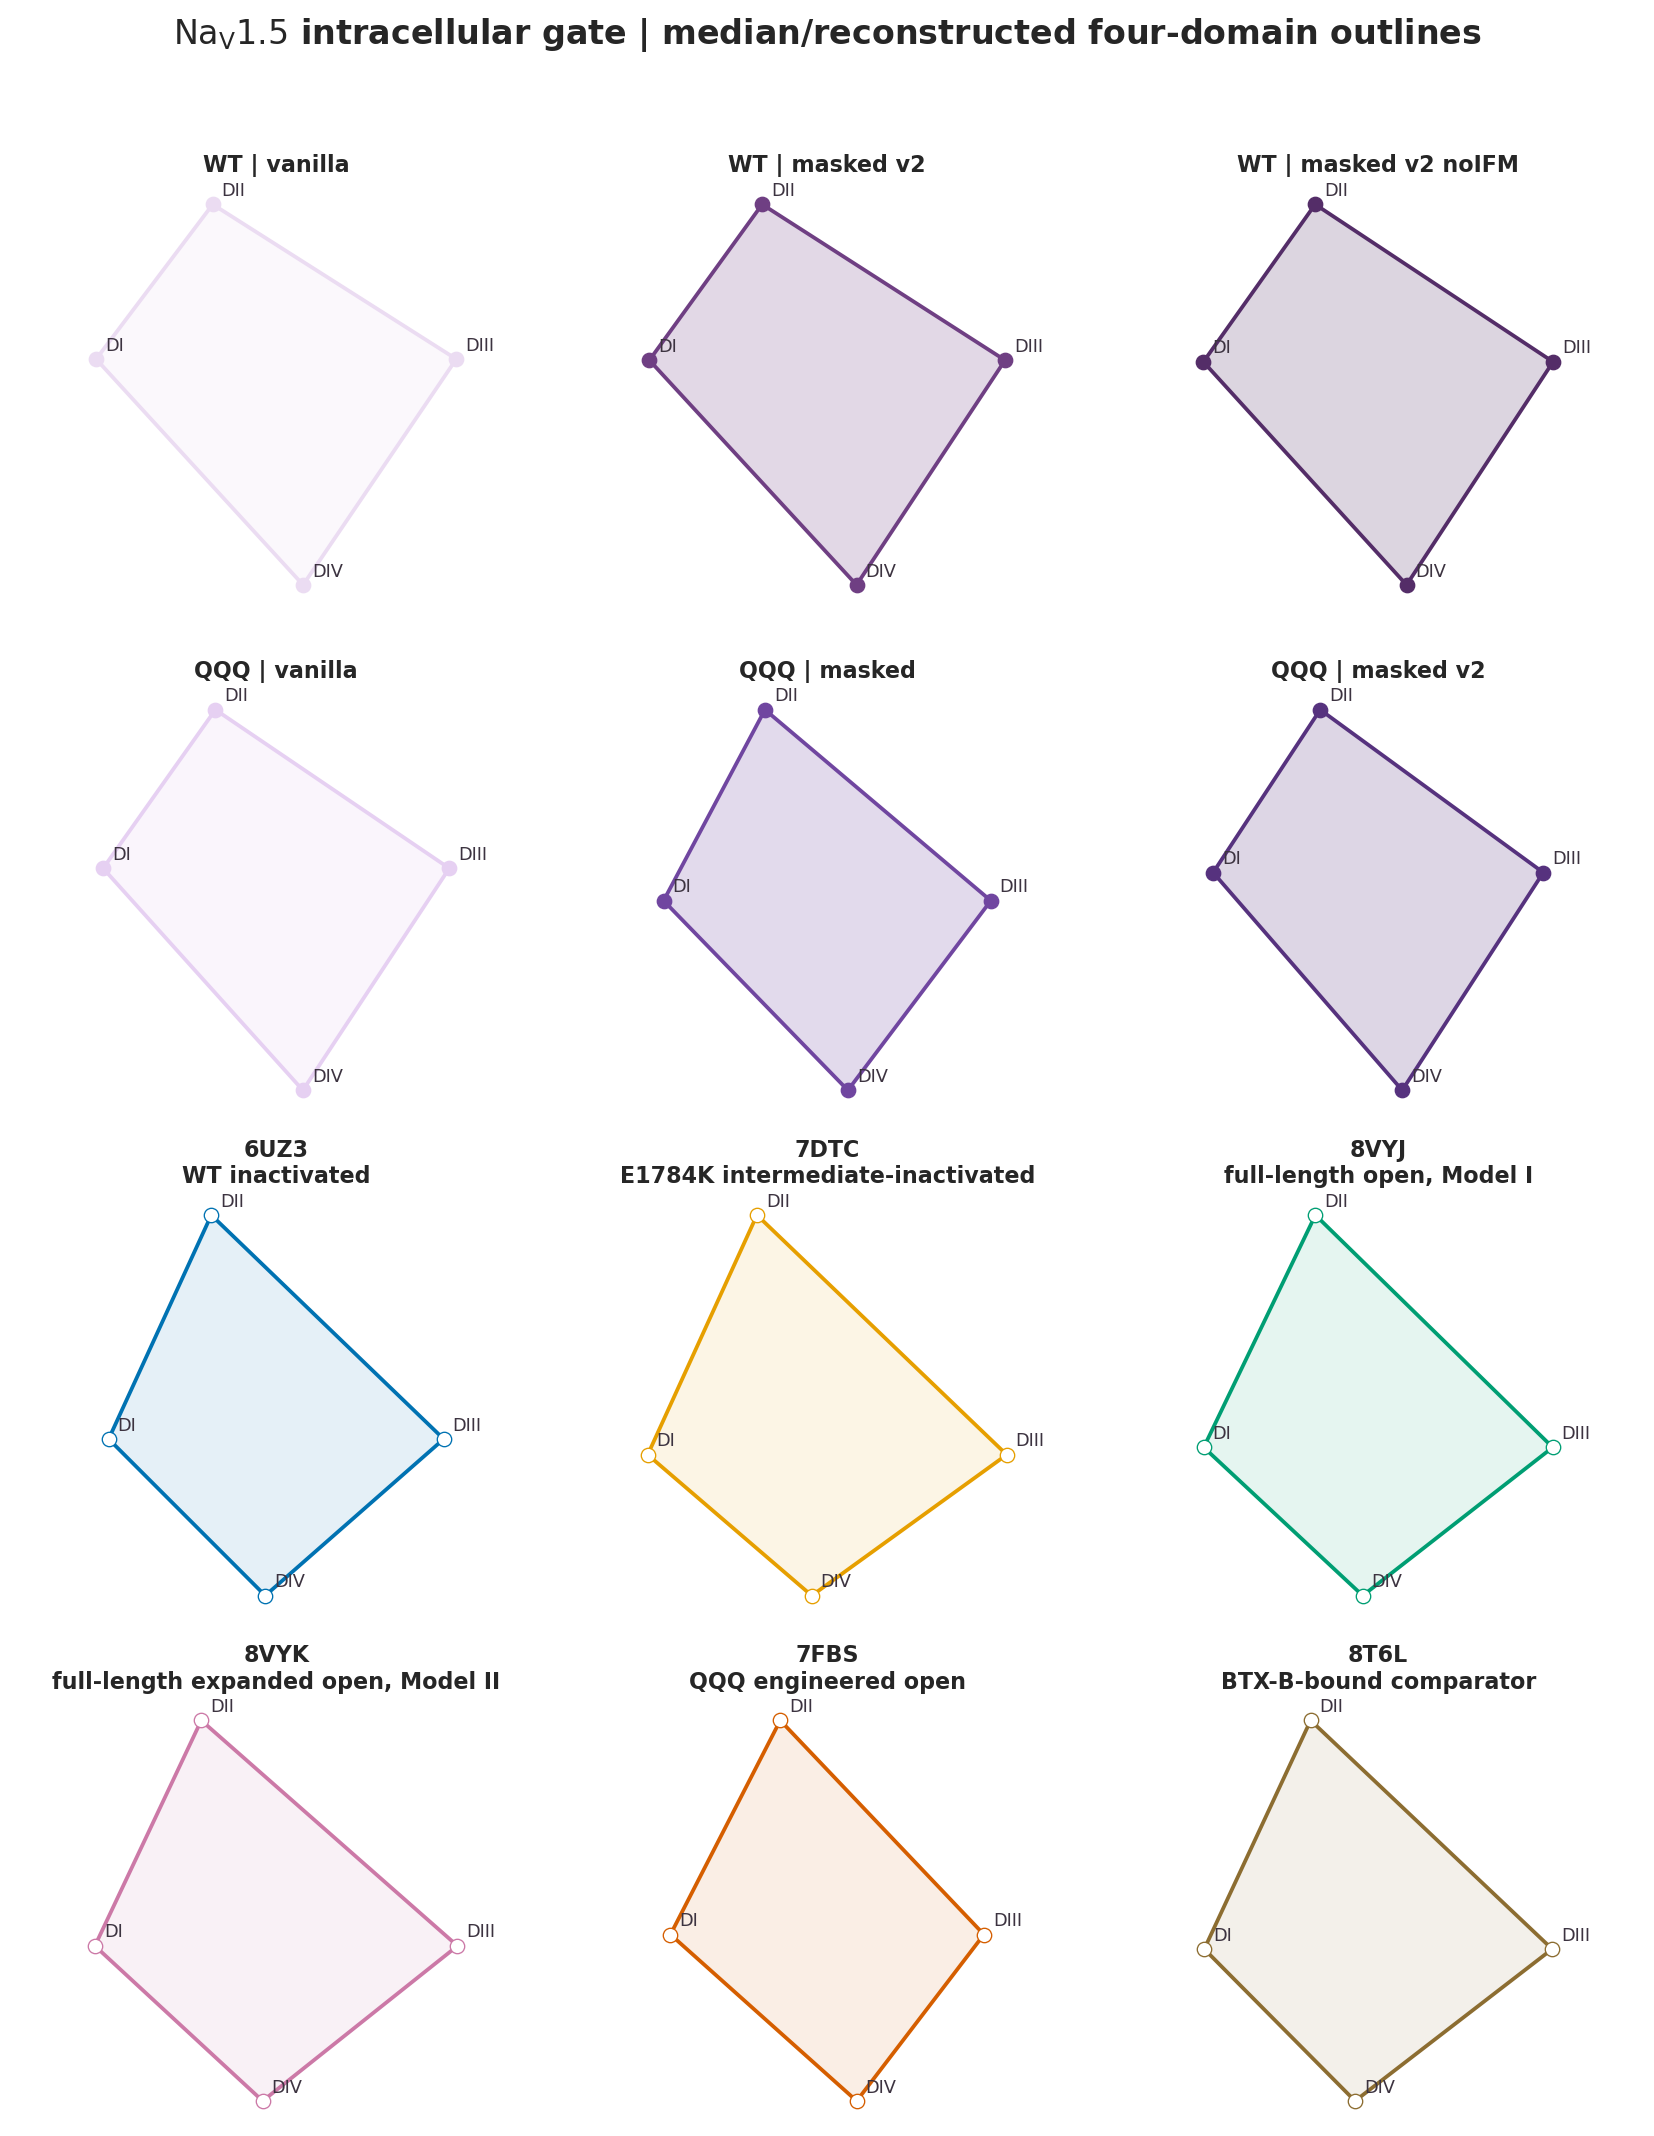

In [5]:
fig, axes = plot_representative_shapes(ensemble_shape, experimental_shape, palette)
fig.savefig(writing_figure_dir / "Nav15_gate_reconstructed_outlines.png", dpi=300, bbox_inches="tight")
fig.savefig(writing_figure_dir / "Nav15_gate_reconstructed_outlines.pdf", bbox_inches="tight")
plt.show()

## Numerical summary and interpretation guardrails

The table reports medians and the central 90% interval. A side aspect ratio near 1 is more square-like; a larger value is more rectangular. Low opposite-side and diagonal mismatch values indicate that the quadrilateral is reasonably rectangle-like. If those mismatch values are large, the outline is better described as irregular rather than simply rectangular.

This analysis is a Cα-level gate proxy. It does not measure the solvent-accessible pore radius and does not by itself assign conducting, activated, or inactivated states. The strongest interpretation comes from combining it with the existing pore-openness, IFM-latching, and VSD-state analyses.

In [6]:
summary = (
    ensemble_shape.groupby("dataset", sort=False)
    .agg(
        n=("model", "size"),
        diagonal_median_A=("mean_diagonal_A", "median"),
        diagonal_q05_A=("mean_diagonal_A", lambda x: x.quantile(0.05)),
        diagonal_q95_A=("mean_diagonal_A", lambda x: x.quantile(0.95)),
        aspect_median=("side_aspect_ratio", "median"),
        aspect_q05=("side_aspect_ratio", lambda x: x.quantile(0.05)),
        aspect_q95=("side_aspect_ratio", lambda x: x.quantile(0.95)),
        opposite_side_mismatch=("opposite_side_mismatch", "median"),
        diagonal_mismatch=("diagonal_mismatch", "median"),
    )
    .reset_index()
)
display(summary.round(3))
summary.to_csv(nav_dir / "dataDistances/analysis/tables/Nav15_pore_shape_summary.csv", index=False)

audit_rows = []
for pdb_id, distances in experimental_distance_audit.items():
    audit_rows.extend({"PDB": pdb_id, "pair": pair, "distance_A": value} for pair, value in distances.items())
pd.DataFrame(audit_rows).to_csv(experimental_dir / "PORE_SHAPE_DISTANCE_AUDIT.tsv", sep="\t", index=False)

,dataset,n,diagonal_median_A,diagonal_q05_A,diagonal_q95_A,aspect_median,aspect_q05,aspect_q95,opposite_side_mismatch,diagonal_mismatch
0,WT | vanilla,5000,15.075,14.295,16.925,1.232,1.158,1.293,0.153,0.110
1,WT | masked v2,4999,15.385,14.485,17.005,1.247,1.146,1.328,0.147,0.113
2,WT | masked v2 noIFM,5000,15.560,14.470,17.060,1.233,1.145,1.321,0.151,0.128
3,QQQ | vanilla,5000,14.970,14.280,16.760,1.220,1.149,1.300,0.150,0.139
4,QQQ | masked,4999,16.500,14.814,17.815,1.180,1.132,1.337,0.123,0.192
5,QQQ | masked v2,5000,15.458,14.265,16.895,1.217,1.141,1.325,0.143,0.186
